# 9.3 — Cross-currency basis y colateral multi-divisa

Cierra M9 y el currículum de tasas/FX (M5-M9). El **cross-currency basis** es la
desviación persistente de la paridad de tasas de interés cubierta (CIP) observada en
mercado desde 2008 — un spread que hay que incorporar al descontar flujos de una divisa
bajo colateral posteado en otra. Se bootstrapea la curva de descuento "consistente con
colateral" usando exactamente la misma técnica de recursión secuencial que el bootstrap
multi-curva OIS-vs-proyección de 5.3, ahora entre dos MONEDAS en vez de dos tenores.

## 0. Configuración

Dos curvas OIS independientes (USD doméstica, EUR extranjera) vía `nelson_siegel_df` con
distintos parámetros — perfiles de tasa genuinamente distintos, para que el límite CIP de
la Sección 2 sea una prueba real (no trivial).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df
from qflib.plotting import apply_style

apply_style()

tau = 0.5
N = 10
T = np.array([tau * (i + 1) for i in range(N)])  # 0.5 .. 5.0

Pd = nelson_siegel_df(T)  # USD OIS (domestica)
Pf = nelson_siegel_df(T, beta0=0.02, beta1=-0.005, beta2=0.005, tau=2.0)  # EUR OIS (extranjera, independiente)
S0 = 1.10  # EUR/USD

print("Pd (USD):", np.round(Pd, 5))
print("Pf (EUR):", np.round(Pf, 5))

Pd (USD): [0.98157 0.96181 0.94137 0.92068 0.90002 0.87958 0.85949 0.8398  0.82057
 0.8018 ]
Pf (EUR): [0.99198 0.98318 0.97389 0.96433 0.95464 0.94492 0.93523 0.92562 0.9161
 0.9067 ]


## 1. Bootstrap de la curva de descuento cross-currency

El basis swap intercambia flotante USD SOFR (flat) por flotante EUR ESTR + spread
$b_i$ (por periodo), ambos con colateral en USD. Igual que el bootstrap de 5.3
(recursión secuencial nodo a nodo), cada periodo debe repreciar a cero, usando el forward
de la propia curva EUR-bajo-colateral-USD que se está construyendo ($P_x$) para su propio
leg, y el forward EUR NATURAL ($P_f$, sin ajuste) para saber cuánto "debería" pagar ese
leg antes del spread:
$$\tau(F_x^{(i)}+b_i)P_x(T_i) = \tau F_f^{(i)} P_f(T_i)$$
con $F_x^{(i)}=\left(\frac{P_x(T_{i-1})}{P_x(T_i)}-1\right)/\tau$ (telescópico, igual que
en 5.2/5.3) — se despeja $P_x(T_i)$ secuencialmente:
$$P_x(T_i) = \frac{P_x(T_{i-1}) - \tau F_f^{(i)} P_f(T_i)}{1-\tau b_i}$$

In [2]:
def basis_spread(Ti):
    '''Basis sintetico: mas negativo en tenores cortos (patron post-2008), decayendo a -20bp largo plazo.'''
    return -0.002 - 0.010 * np.exp(-Ti / 2.0)


basis = basis_spread(T)

Pf_full = np.concatenate([[1.0], Pf])
Ff = (Pf_full[:-1] / Pf_full[1:] - 1.0) / tau


def bootstrap_px(basis_arr):
    Px = np.zeros(N)
    prev = 1.0
    for i in range(N):
        Px[i] = (prev - tau * Ff[i] * Pf[i]) / (1.0 - tau * basis_arr[i])
        prev = Px[i]
    return Px


Px = bootstrap_px(basis)
print("basis (bp):", np.round(basis * 1e4, 2))
print("Px (EUR bajo colateral USD):", np.round(Px, 5))

basis (bp): [-97.88 -80.65 -67.24 -56.79 -48.65 -42.31 -37.38 -33.53 -30.54 -28.21]
Px (EUR bajo colateral USD): [0.98715 0.97442 0.9619  0.94964 0.93767 0.92599 0.91459 0.90346 0.89258
 0.88193]


### Demo 1 — reprecio exacto de los swaps cross-currency de entrada

Si el bootstrap está bien hecho, la condición que define cada $b_i$ (premium leg del basis swap igual a protection leg, en la notación de la Sección 1) debe cumplirse EXACTAMENTE en cada periodo por separado — no solo en promedio.

In [3]:
Px_full = np.concatenate([[1.0], Px])
Fx = (Px_full[:-1] / Px_full[1:] - 1.0) / tau
per_period_diff = tau * (Fx + basis) * Px - tau * Ff * Pf
max_reprice_diff = np.max(np.abs(per_period_diff))
print(f"maxima diferencia de reprecio por periodo: {max_reprice_diff:.2e}")

maxima diferencia de reprecio por periodo: 1.46e-16


### Demo 2 — curva con basis vs sin basis, y el basis implícito recuperado

Comparamos la curva EUR bajo colateral USD ($P_x$, la que de verdad hay que usar para descontar flujos EUR colateralizados en USD) contra la curva EUR natural ($P_f$, sin ajuste) — la brecha entre ambas es exactamente lo que el basis de mercado está cobrando.

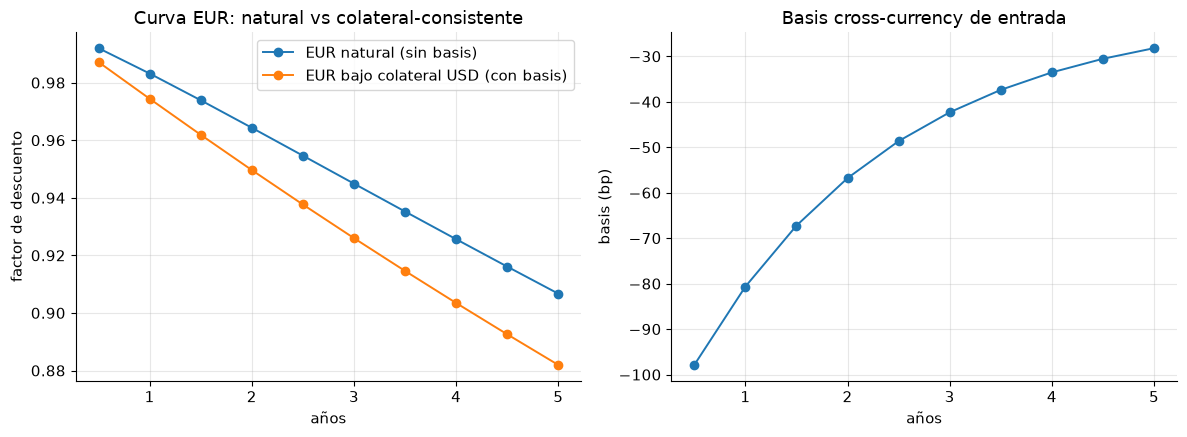

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(T, Pf, "o-", label="EUR natural (sin basis)")
axes[0].plot(T, Px, "o-", label="EUR bajo colateral USD (con basis)")
axes[0].set_xlabel("años"); axes[0].set_ylabel("factor de descuento")
axes[0].set_title("Curva EUR: natural vs colateral-consistente"); axes[0].legend()

axes[1].plot(T, basis * 1e4, "o-")
axes[1].set_xlabel("años"); axes[1].set_ylabel("basis (bp)")
axes[1].set_title("Basis cross-currency de entrada")
fig.tight_layout(); plt.show()

## 2. Forward FX ajustado por CSA, y el límite de paridad de tasas cubierta (CIP)

Con colateral en USD, el forward FX relevante para un derivado EUR usa la curva
COLATERAL-CONSISTENTE $P_x$ (no la EUR natural $P_f$):
$$F_{CSA}(T) = S_0\,\frac{P_x(T)}{P_d(T)}$$
En el límite $b\to0$ (sin basis, CSA en la moneda natural de cada leg), el bootstrap de
la Sección 1 da $P_x\to P_f$ exactamente (se verificó algebraicamente arriba: con $b=0$ la
recursión colapsa a la identidad que define $P_f$ desde sus propios forwards) — recuperando
la paridad de tasas cubierta estándar:
$$F_{CIP}(T) = S_0\,\frac{P_f(T)}{P_d(T)}$$

F_CSA (con basis):        [1.10626 1.11441 1.12398 1.1346  1.14602 1.15804 1.17053 1.18338 1.19654
 1.20994]
F_CIP (sin basis):        [1.11167 1.12443 1.13799 1.15215 1.16676 1.18171 1.19694 1.2124  1.22806
 1.24391]
F_CSA con basis=0:        [1.11167 1.12443 1.13799 1.15215 1.16676 1.18171 1.19694 1.2124  1.22806
 1.24391]
diferencia relativa (limite basis->0 vs CIP): 3.57e-16


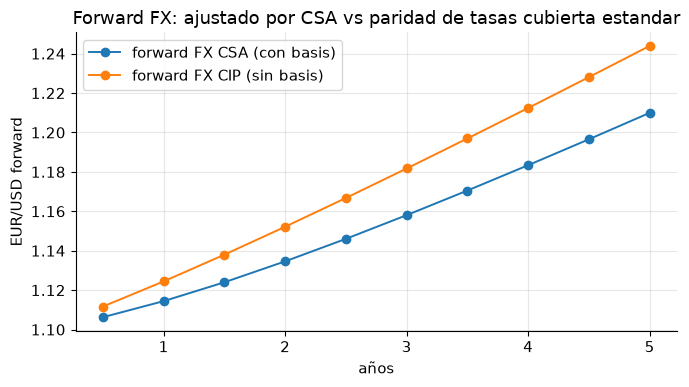

In [5]:
F_csa = S0 * Px / Pd
F_cip = S0 * Pf / Pd

Px_nobasis = bootstrap_px(np.zeros(N))
F_csa_nobasis = S0 * Px_nobasis / Pd
rel_diff_cip = np.max(np.abs(F_csa_nobasis - F_cip)) / np.max(np.abs(F_cip))

print(f"F_CSA (con basis):        {np.round(F_csa, 5)}")
print(f"F_CIP (sin basis):        {np.round(F_cip, 5)}")
print(f"F_CSA con basis=0:        {np.round(F_csa_nobasis, 5)}")
print(f"diferencia relativa (limite basis->0 vs CIP): {rel_diff_cip:.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T, F_csa, "o-", label="forward FX CSA (con basis)")
ax.plot(T, F_cip, "o-", label="forward FX CIP (sin basis)")
ax.set_xlabel("años"); ax.set_ylabel("EUR/USD forward")
ax.set_title("Forward FX: ajustado por CSA vs paridad de tasas cubierta estandar")
ax.legend(); fig.tight_layout(); plt.show()

## 3. Sensibilidad: basis01

Análogo al DV01 con signo de 5.5: shock paralelo de +1bp en el basis, ¿cómo se mueve $P_x$
(y por tanto el valor de un swap cross-currency)? El signo debe ser consistente en todos
los tenores (no solo su magnitud).

In [6]:
shock = 1e-4  # +1bp
Px_shocked = bootstrap_px(basis + shock)
basis01 = Px_shocked - Px
same_sign = np.all(basis01 > 0) or np.all(basis01 < 0)
print(f"basis01 (Px shift por +1bp de basis): {np.round(basis01 * 1e4, 4)}")
print(f"signo consistente en todos los tenores: {same_sign}")

basis01 (Px shift por +1bp de basis): [0.4912 0.9745 1.4507 1.9201 2.3833 2.8404 3.2917 3.7374 4.1775 4.6122]
signo consistente en todos los tenores: True


## 4. Validación

Tres chequeos: (1) el reprecio exacto de la Demo 1; (2) el límite $b\to0$ recupera la paridad de tasas cubierta estándar (la identidad algebraica de la Sección 2); (3) el basis01 tiene signo consistente en todos los tenores, igual que el DV01 con signo de 5.5.

In [7]:
check1 = max_reprice_diff < 1e-10
print(f"1. reprecio exacto de los swaps cross-currency de entrada: max diff={max_reprice_diff:.2e} (<1e-10? {check1})")

check2 = rel_diff_cip < 1e-6
print(f"2. limite basis=0 recupera CIP estandar: diff relativa={rel_diff_cip:.2e} (<1e-6? {check2})")

check3 = same_sign
print(f"3. basis01 tiene signo consistente en todos los tenores: {check3}")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. reprecio exacto de los swaps cross-currency de entrada: max diff=1.46e-16 (<1e-10? True)
2. limite basis=0 recupera CIP estandar: diff relativa=3.57e-16 (<1e-6? True)
3. basis01 tiene signo consistente en todos los tenores: True

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Du, W., Tepper, A., Verdelhan, A. (2018). *Deviations from Covered Interest Rate
  Parity*. Journal of Finance, 73(3), 915-957.
- Fujii, M., Shimada, Y., Takahashi, A. (2010). *A Note on Construction of Multiple Swap
  Curves with and without Collateral*.
- Piterbarg, V. (2010). *Funding beyond discounting: collateral agreements and
  derivatives pricing*. Risk, 23(2), 97-102.